## week 7 data visualization homework

digma, ronachel marie of h3101

### imports and load finalized datasets

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# load datasets
customers = pd.read_csv(
    "../data/processed/customer_demographics_preprocessed.csv"
)

transactions = pd.read_csv(
    "../data/processed/customer_transactions_preprocessed.csv"
)

social_media = pd.read_csv(
    "../data/processed/social_media_interactions_preprocessed.csv"
)

### inspect

In [31]:
print("Customer Demographics:", customers.shape)
print("Transactions:", transactions.shape)
print("Social Media:", social_media.shape)

# display first few rows of the datasets
display(customers.head())
display(transactions.head())
display(social_media.head())

Customer Demographics: (3000, 6)
Transactions: (3015, 6)
Social Media: (3020, 6)


,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate
0,0009fdd2-ae63-45ca-8d5b-d0ea98381f7b,21.0,Female,Lake George,Low,2020-11-09
1,000c6bbd-533a-432d-922c-ab64197e71c5,25.0,Male,North Oliviaton,High,2019-11-06
2,00115fc0-f155-42cd-ba68-58aab67b3360,36.0,Male,Nelsonstad,Low,2022-02-16
3,00145374-004a-4685-af4d-c8a8967b969e,69.0,Female,Jacquelinehaven,Unknown,2023-04-28
4,0047d8ce-a5bb-4db7-860f-6ff66e1cd060,40.0,Male,Mitchellview,Medium,2021-11-11


,CustomerID,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod
0,60567026-f719-4cd6-849e-137e86d8938f,5ff75116-0a50-4d04-80fb-31e5ccbb0769,2024-05-15,117.64,Clothing,PayPal
1,4090ba85-b111-4f75-a792-c777965f5255,2c39b9fe-ff57-4d39-9321-9f5cdf187aa1,2023-04-26,466.14,Health & Beauty,Bank Transfer
2,9223891b-73ff-4d5c-b8ae-13ece82ee28b,f79588dd-3db9-4ffa-97f8-7de0e64259f1,2022-09-23,563.99,Clothing,Debit Card
3,9243eebc-938f-480c-8564-16d503d250de,401c0fc9-60df-4455-ad78-67c132f9897d,2024-04-15,254.44,Automotive,PayPal
4,6e3e8eb8-bc0f-4ffe-9f74-5d5efec9502f,2034aebc-8280-4254-a667-92bcd1c2be4f,2024-06-03,590.52,Home & Garden,Bank Transfer


,CustomerID,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
0,2dcb9523-356b-40b2-a67b-1f27797de261,e5d15761-d0a7-4329-89e3-79a892c56097,2023-07-11,Unknown,Comment,Unknown
1,e12c37b3-7d4d-472f-9fd8-0df2cb3001aa,02f9f376-70ae-4fcd-9070-1db977939948,2023-07-06,Twitter,Share,Unknown
2,08a911a3-65e6-4f5d-a6a1-ae7ddcbe28a2,a83fa04c-f109-4f24-8ce1-2078154f6a1c,2024-05-24,Instagram,Comment,Neutral
3,efdfdfc9-5dbb-4478-911a-101a390a0285,28a69c4b-a2e4-4c74-a130-1132d7733fdf,2023-11-01,Instagram,Like,Neutral
4,ca1e90f6-0e5f-492e-ab92-252ff540da18,d9d1c6f8-5e15-4738-b52b-13c2982420cc,2023-07-08,Instagram,Like,Unknown


### data verification

In [32]:
print("Customer-level observations:", len(customers))
print("Transaction-level observations:", len(transactions))
print("Social-media interaction-level observations:", len(social_media))

# make sure there are no missing values
print("\nMissing values:")
print("\nCustomer Demographics")
display(customers.isna().sum())

print("\nTransactions")
display(transactions.isna().sum())

print("\nSocial Media")
display(social_media.isna().sum())

Customer-level observations: 3000
Transaction-level observations: 3015
Social-media interaction-level observations: 3020

Missing values:

Customer Demographics


CustomerID     0
Age            0
Gender         0
Location       0
IncomeLevel    0
SignupDate     0
dtype: int64


Transactions


CustomerID         0
TransactionID      0
TransactionDate    0
Amount             0
ProductCategory    0
PaymentMethod      0
dtype: int64


Social Media


CustomerID         0
InteractionID      0
InteractionDate    0
Platform           0
InteractionType    0
Sentiment          0
dtype: int64

### numerical analysis

#### demographics

In [33]:
age = customers["Age"].to_numpy()

age_mean = np.mean(age)
age_median = np.median(age)
age_std = np.std(age, ddof=1)
age_variance = np.var(age, ddof=1)
age_min = np.min(age)
age_max = np.max(age)

print("Age Mean:", age_mean)
print("Age Median:", age_median)
print("Age Standard Deviation:", age_std)
print("Age Variance:", age_variance)
print("Age Minimum:", age_min)
print("Age Maximum:", age_max)

Age Mean: 44.66433333333333
Age Median: 45.0
Age Standard Deviation: 14.452818267527626
Age Variance: 208.88395587418023
Age Minimum: 18.0
Age Maximum: 70.0


#### transactions

In [34]:
amount = transactions["Amount"].to_numpy()

amount_mean = np.mean(amount)
amount_median = np.median(amount)
amount_std = np.std(amount, ddof=1)
amount_variance = np.var(amount, ddof=1)
amount_min = np.min(amount)
amount_max = np.max(amount)

print("Transaction Amount Mean:", amount_mean)
print("Transaction Amount Median:", amount_median)
print("Transaction Amount Standard Deviation:", amount_std)
print("Transaction Amount Variance:", amount_variance)
print("Transaction Amount Minimum:", amount_min)
print("Transaction Amount Maximum:", amount_max)

# calculate pencentiles
amount_percentiles = np.percentile(
    transactions["Amount"],
    [25, 50, 75]
)

print("Transaction Amount Percentiles:", amount_percentiles)

Transaction Amount Mean: 499.2938905472637
Transaction Amount Median: 504.14
Transaction Amount Standard Deviation: 274.8862910795029
Transaction Amount Variance: 75562.4730234452
Transaction Amount Minimum: 0.0
Transaction Amount Maximum: 999.86
Transaction Amount Percentiles: [269.845 504.14  720.395]


### visualization

In [35]:
from pathlib import Path

# output directory for visualization files
OUTPUT_DIR = Path("visualization_outputs")

# create subfolders
DEMOGRAPHICS_DIR = OUTPUT_DIR / "demographics"
TRANSACTIONS_DIR = OUTPUT_DIR / "transactions"
SOCIAL_MEDIA_DIR = OUTPUT_DIR / "social_media"
CROSS_DATASET_DIR = OUTPUT_DIR / "cross_dataset"

for folder in [DEMOGRAPHICS_DIR, TRANSACTIONS_DIR, SOCIAL_MEDIA_DIR, CROSS_DATASET_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def save_figure(filename, folder):
    """Save the current Matplotlib figure as a high-resolution PNG."""
    filepath = folder / filename
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath}")

#### customer demographics

Saved: visualization_outputs\demographics\age_distribution.png


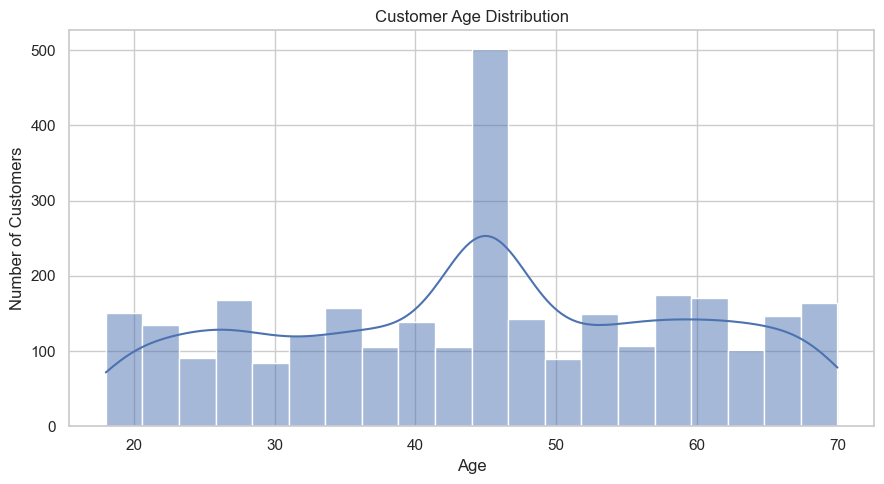

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=customers,
    x="Age",
    bins=20,
    kde=True,
    ax=ax
)

ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")

save_figure("age_distribution.png", DEMOGRAPHICS_DIR)

the histogram shows the distribution of customer ages across the finalized demographic dataset. the distribution is concentrated around the central age range, while fewer observations occur toward the extremes. this provides descriptive information that can guide later age-based feature engineering and scaling decisions, but the distribution alone does not establish that age predicts customer spending.

#### gender distribution

Saved: visualization_outputs\demographics\gender_distribution.png


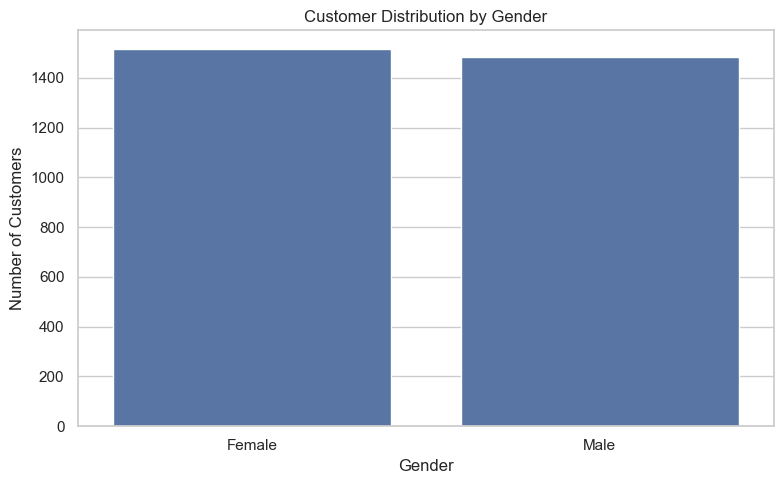

Gender
Female    50.5
Male      49.5
Name: proportion, dtype: float64

In [37]:
gender_counts = customers["Gender"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
save_figure("gender_distribution.png", DEMOGRAPHICS_DIR)
plt.show()

# calculate percentages
gender_percent = (
    customers["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(gender_percent)

#### income level

Saved: visualization_outputs\demographics\income_level_distribution.png


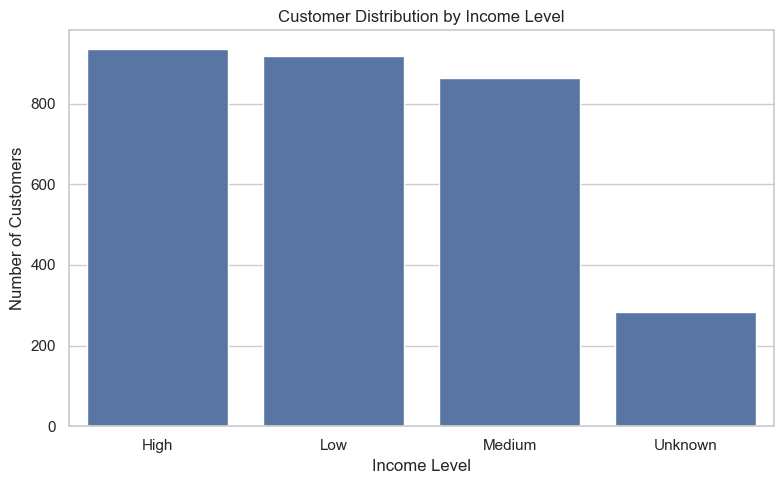

IncomeLevel
High       31.17
Low        30.60
Medium     28.77
Unknown     9.47
Name: proportion, dtype: float64

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

income_counts = customers["IncomeLevel"].value_counts()

sns.barplot(
    x=income_counts.index,
    y=income_counts.values,
    ax=ax
)

ax.set_title("Customer Distribution by Income Level")
ax.set_xlabel("Income Level")
ax.set_ylabel("Number of Customers")

save_figure("income_level_distribution.png", DEMOGRAPHICS_DIR)
plt.show()

# calculate percentage
income_percent = (
    customers["IncomeLevel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(income_percent)

### customer transactions

#### transaction amount distribution

Saved: visualization_outputs\transactions\transaction_amount_distribution.png


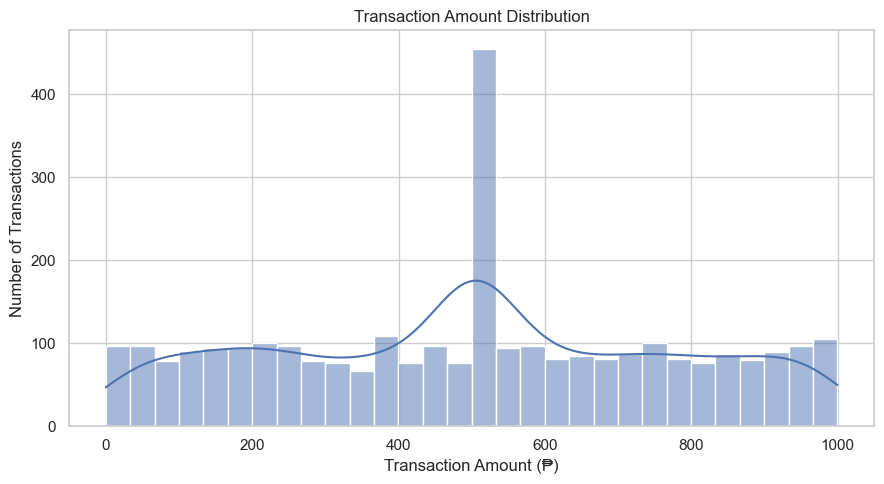

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=transactions,
    x="Amount",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Transaction Amount Distribution")
ax.set_xlabel("Transaction Amount (₱)")
ax.set_ylabel("Number of Transactions")
save_figure("transaction_amount_distribution.png", TRANSACTIONS_DIR)

Saved: visualization_outputs\transactions\transaction_amount_boxplot.png


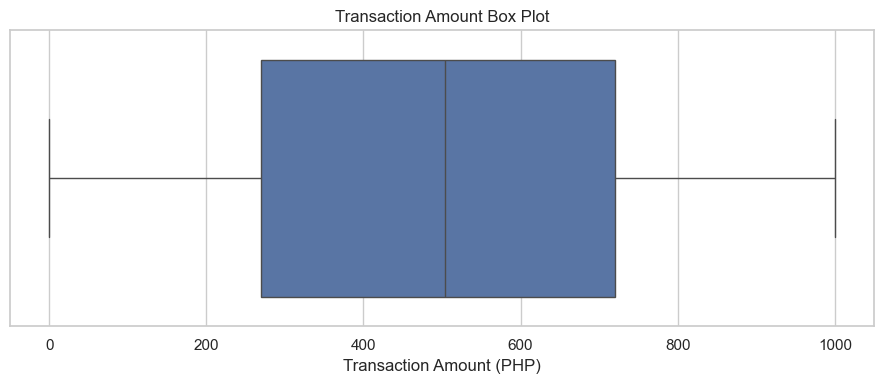

In [40]:
# boxplot
fig, ax = plt.subplots(figsize=(9, 4))

sns.boxplot(
    data=transactions,
    x="Amount",
    ax=ax
)

ax.set_title("Transaction Amount Box Plot")
ax.set_xlabel("Transaction Amount (PHP)")

save_figure("transaction_amount_boxplot.png", TRANSACTIONS_DIR)


the box plot identifies observations that may be statistically unusual relative to the overall transaction distribution. these observations should be investigated according to their business meaning rather than automatically removed.

#### product categories

Saved: visualization_outputs\transactions\product_category_frequency.png


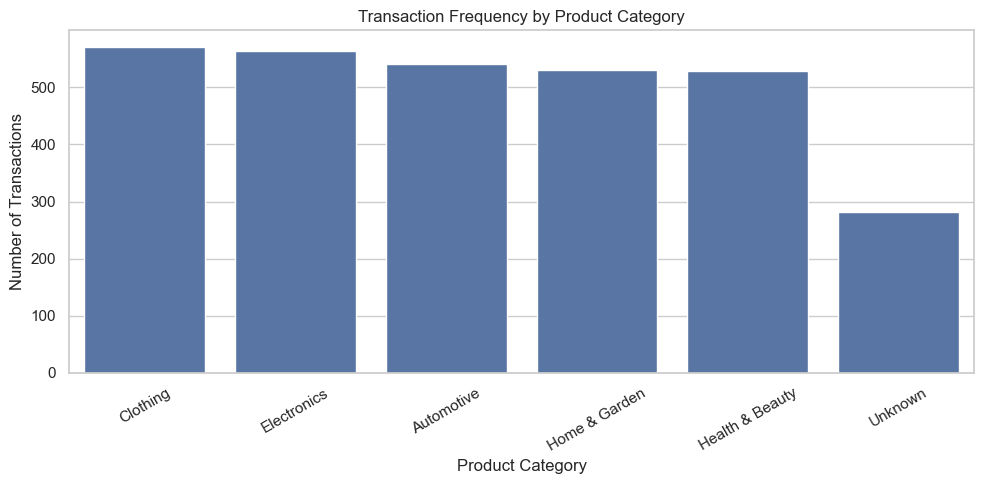

In [41]:
# transaction frequency by category
fig, ax = plt.subplots(figsize=(10, 5))

category_counts = (
    transactions["ProductCategory"]
    .value_counts()
)

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    ax=ax
)

ax.set_title("Transaction Frequency by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Number of Transactions")

ax.tick_params(axis="x", rotation=30)

save_figure("product_category_frequency.png", TRANSACTIONS_DIR)

Saved: visualization_outputs\transactions\average_transaction_amount_by_category.png


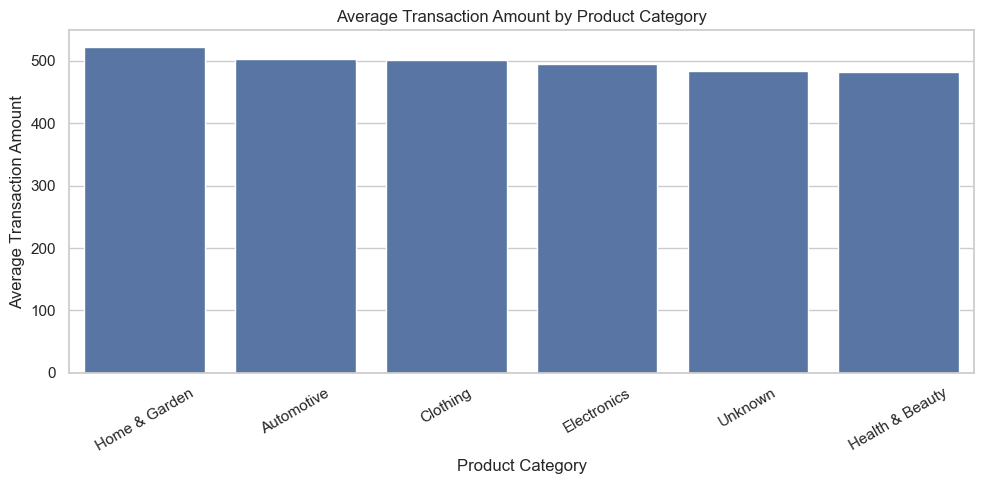

In [42]:
# average transaction amount
avg_amount = (
    transactions
    .groupby("ProductCategory")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=avg_amount.index,
    y=avg_amount.values
)

plt.title("Average Transaction Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()

save_figure("average_transaction_amount_by_category.png", TRANSACTIONS_DIR)
plt.show()

#### payment methods

Saved: visualization_outputs\transactions\payment_method_frequency.png


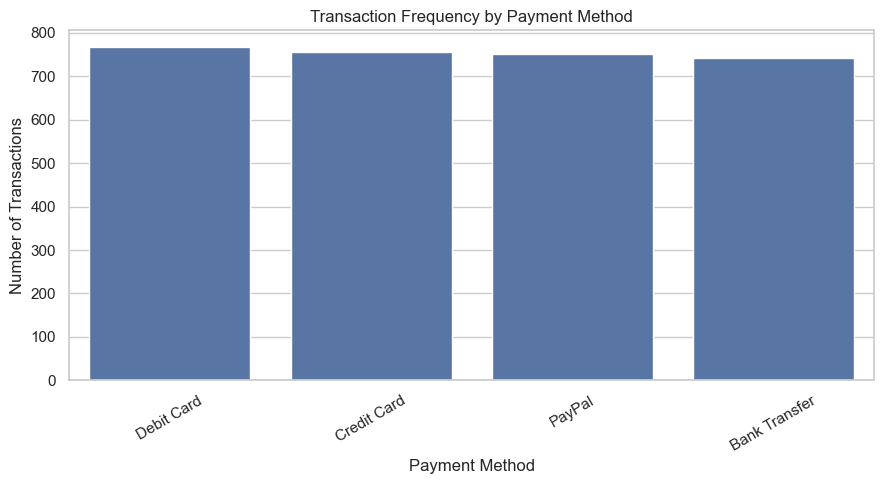

In [43]:
# payment method frequency
plt.figure(figsize=(9, 5))

sns.countplot(
    data=transactions,
    x="PaymentMethod",
    order=transactions["PaymentMethod"].value_counts().index
)

plt.title("Transaction Frequency by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()

save_figure("payment_method_frequency.png", TRANSACTIONS_DIR)
plt.show()

#### transaction trends

In [44]:
# convert to date first
transactions["TransactionDate"] = pd.to_datetime(
    transactions["TransactionDate"],
    errors="coerce"
)

In [45]:
monthly_transactions = (
    transactions
    .dropna(subset=["TransactionDate"])
    .set_index("TransactionDate")
    .resample("ME")
    .size()
)

Saved: visualization_outputs\transactions\monthly_transaction_volume.png


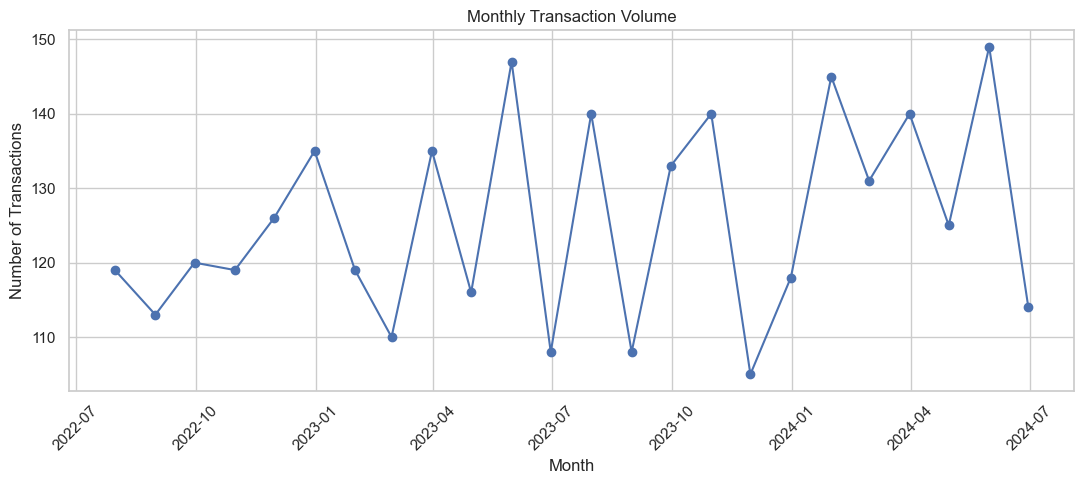

In [46]:
# monthly transaction volume
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_transactions.index,
    monthly_transactions.values,
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()

save_figure("monthly_transaction_volume.png", TRANSACTIONS_DIR)
plt.show()

### social media interactions

In [47]:
# inspect column names first then use the actual categorical fields
print(social_media.columns.tolist())

['CustomerID', 'InteractionID', 'InteractionDate', 'Platform', 'InteractionType', 'Sentiment']


Saved: visualization_outputs\social_media\platform_distribution.png


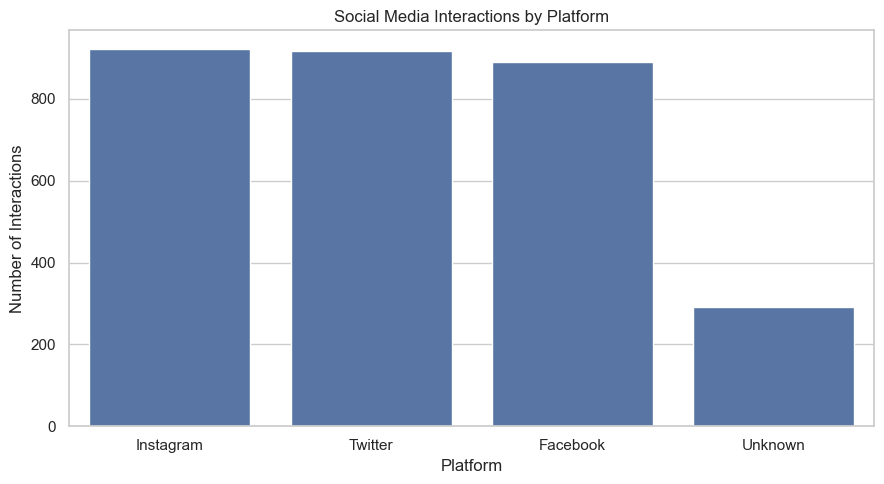

In [48]:
# platfirm
plt.figure(figsize=(9, 5))

sns.countplot(
    data=social_media,
    x="Platform",
    order=social_media["Platform"].value_counts().index
)

plt.title("Social Media Interactions by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Interactions")
plt.tight_layout()

save_figure("platform_distribution.png", SOCIAL_MEDIA_DIR)
plt.show()

Saved: visualization_outputs\social_media\interaction_type_distribution.png


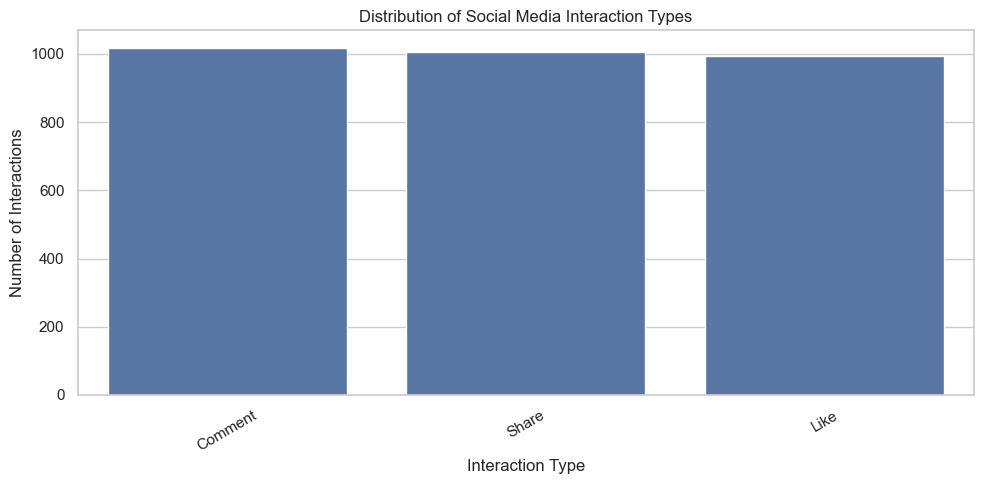

In [49]:
# interaction type
plt.figure(figsize=(10, 5))

sns.countplot(
    data=social_media,
    x="InteractionType",
    order=social_media["InteractionType"].value_counts().index
)

plt.title("Distribution of Social Media Interaction Types")
plt.xlabel("Interaction Type")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=30)
plt.tight_layout()

save_figure("interaction_type_distribution.png", SOCIAL_MEDIA_DIR)
plt.show()

Saved: visualization_outputs\social_media\sentiment_distribution.png


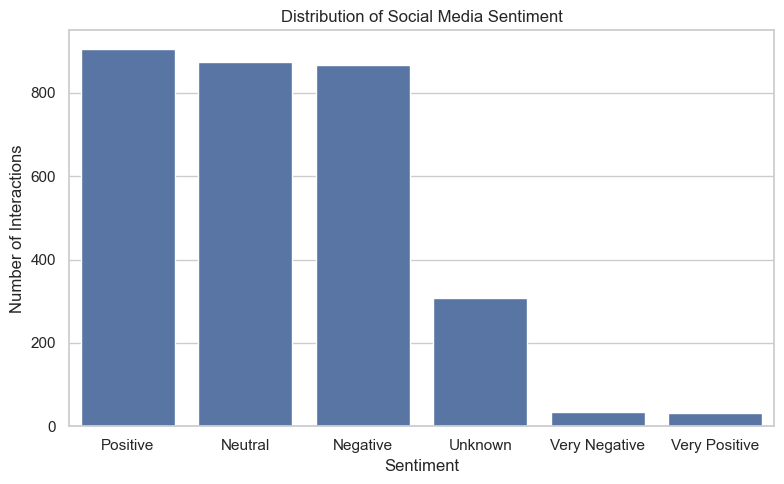

In [50]:
# sentiment
plt.figure(figsize=(8, 5))

sns.countplot(
    data=social_media,
    x="Sentiment",
    order=social_media["Sentiment"].value_counts().index
)

plt.title("Distribution of Social Media Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Interactions")
plt.tight_layout()

save_figure("sentiment_distribution.png", SOCIAL_MEDIA_DIR)
plt.show()

the sentiment distribution is uneven, with some sentiment classes occurring less frequently than others. this imbalance may become relevant if sentiment is later used as a prediction target because minority classes may require appropriate evaluation metrics or resampling strategies.

### cross-dataset analysis
to examine relationships across the datasets, transaction-level and social-media interaction-level records are aggregated to the customer level using customer id. this prevents inappropriate row-level merging across datasets with different observational grains.

the analysis focuses on age, total spend, transaction count, and interaction count to evaluate customer-level relationships relevant to future machine-learning feature engineering.

In [51]:
# transaction-level aggregation
transaction_summary = (
    transactions
    .groupby("CustomerID")
    .agg(
        TotalSpend=("Amount", "sum"),
        TransactionCount=("TransactionID", "count"),
        AverageTransactionAmount=("Amount", "mean")
    )
    .reset_index()
)

# social-media interaction-level aggregation
interaction_summary = (
    social_media
    .groupby("CustomerID")
    .size()
    .reset_index(name="InteractionCount")
)

# combine customer demographics with aggregated transaction data
customer_analysis = (
    customers[
        ["CustomerID", "Age", "Gender", "IncomeLevel"]
    ]
    .merge(
        transaction_summary,
        on="CustomerID",
        how="left"
    )
    .merge(
        interaction_summary,
        on="CustomerID",
        how="left"
    )
)

# customers with no recorded transactions/interactions receive zero
customer_analysis["TotalSpend"] = customer_analysis["TotalSpend"].fillna(0)
customer_analysis["TransactionCount"] = customer_analysis["TransactionCount"].fillna(0)
customer_analysis["InteractionCount"] = customer_analysis["InteractionCount"].fillna(0)

print("Customer-level dataset shape:", customer_analysis.shape)
display(customer_analysis.head())

Customer-level dataset shape: (3000, 8)


,CustomerID,Age,Gender,IncomeLevel,TotalSpend,TransactionCount,AverageTransactionAmount,InteractionCount
0,0009fdd2-ae63-45ca-8d5b-d0ea98381f7b,21.0,Female,Low,389.69,1.0,389.69,2.0
1,000c6bbd-533a-432d-922c-ab64197e71c5,25.0,Male,High,0.00,0.0,NaN,4.0
2,00115fc0-f155-42cd-ba68-58aab67b3360,36.0,Male,Low,445.48,2.0,222.74,0.0
3,00145374-004a-4685-af4d-c8a8967b969e,69.0,Female,Unknown,0.00,0.0,NaN,2.0
4,0047d8ce-a5bb-4db7-860f-6ff66e1cd060,40.0,Male,Medium,259.47,1.0,259.47,0.0


Pearson correlation between Age and TotalSpend: -0.003
Saved: visualization_outputs\cross_dataset\age_vs_total_spend.png


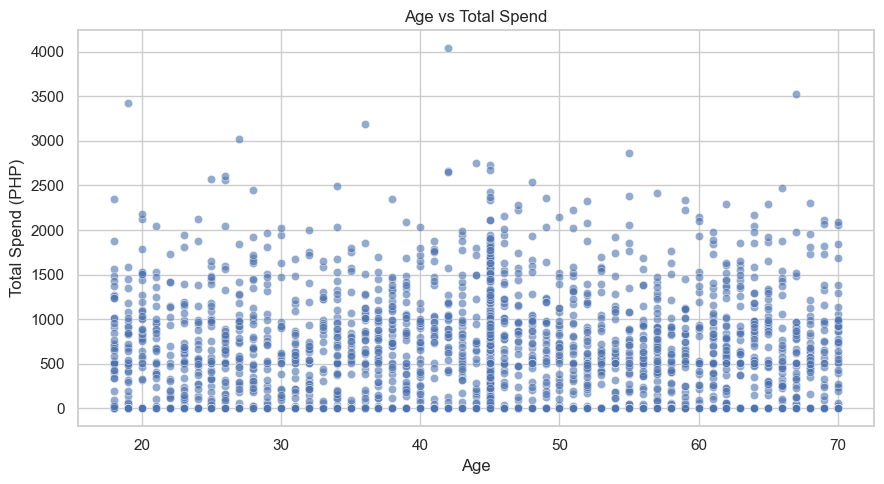

In [52]:
age_spend = customer_analysis[
    ["Age", "TotalSpend"]
].dropna()

age_spend_corr = age_spend["Age"].corr(age_spend["TotalSpend"])

print(f"Pearson correlation between Age and TotalSpend: {age_spend_corr:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=age_spend,
    x="Age",
    y="TotalSpend",
    alpha=0.6,
    ax=ax
)

ax.set_title("Age vs Total Spend")
ax.set_xlabel("Age")
ax.set_ylabel("Total Spend (PHP)")

save_figure("age_vs_total_spend.png", CROSS_DATASET_DIR)

the scatter plot shows little to no clear linear relationship between age and total spend. the correlation is approximately -0.003, indicating that changes in age are not meaningfully associated with changes in total spending in the current data. however, this does not rule out nonlinear or conditional relationships.

Pearson correlation between TransactionCount and TotalSpend: 0.878
Saved: visualization_outputs\cross_dataset\transaction_count_vs_total_spend.png


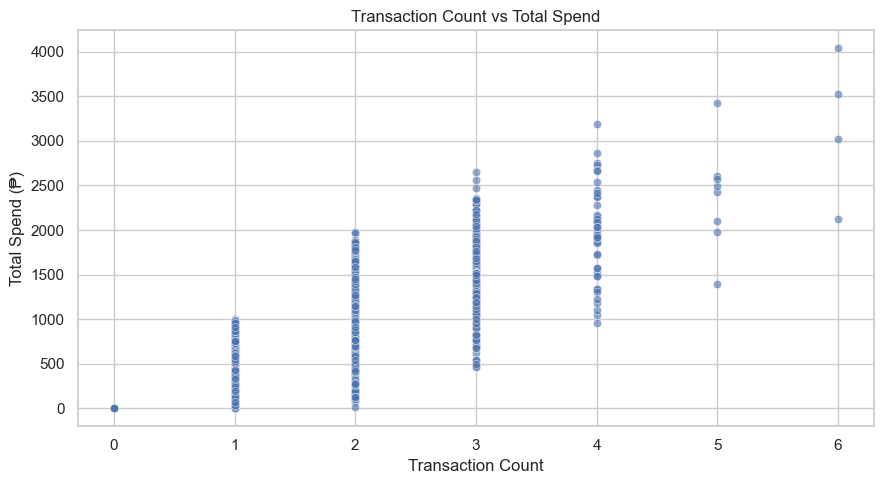

In [53]:
# transaction count vs total spend
transaction_spend = customer_analysis[
    ["TransactionCount", "TotalSpend"]
].dropna()

transaction_spend_corr = (
    transaction_spend["TransactionCount"]
    .corr(transaction_spend["TotalSpend"])
)

print(
    f"Pearson correlation between TransactionCount "
    f"and TotalSpend: {transaction_spend_corr:.3f}"
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=transaction_spend,
    x="TransactionCount",
    y="TotalSpend",
    alpha=0.6,
    ax=ax
)

ax.set_title("Transaction Count vs Total Spend")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Total Spend (₱)")

save_figure("transaction_count_vs_total_spend.png", CROSS_DATASET_DIR)

the scatter plot shows a strong positive relationship between transaction count and total spend, with a correlation of approximately 0.878. customers with more transactions generally have higher total spending. however, this relationship is partly structural because both variables are calculated from the same transaction records, so it should not be interpreted as a causal relationship.

Pearson correlation between InteractionCount and TotalSpend: -0.006
Saved: visualization_outputs\cross_dataset\interaction_count_vs_total_spend.png


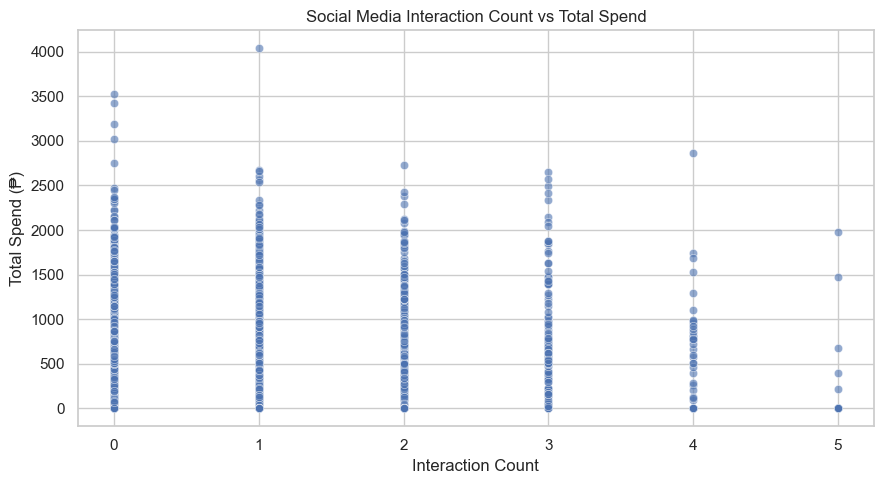

In [54]:
# interaction count vs total spend
interaction_spend = customer_analysis[
    ["InteractionCount", "TotalSpend"]
].dropna()

interaction_spend_corr = (
    interaction_spend["InteractionCount"]
    .corr(interaction_spend["TotalSpend"])
)

print(
    f"Pearson correlation between InteractionCount "
    f"and TotalSpend: {interaction_spend_corr:.3f}"
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=interaction_spend,
    x="InteractionCount",
    y="TotalSpend",
    alpha=0.6,
    ax=ax
)

ax.set_title("Social Media Interaction Count vs Total Spend")
ax.set_xlabel("Interaction Count")
ax.set_ylabel("Total Spend (₱)")

save_figure("interaction_count_vs_total_spend.png", CROSS_DATASET_DIR)


the scatter plot shows little to no clear linear relationship between social media interaction count and total spend. the correlation is approximately -0.006, indicating that interaction frequency has almost no linear association with spending in the current data. this does not exclude possible nonlinear or more complex relationships.

Saved: visualization_outputs\cross_dataset\customer_level_correlation.png


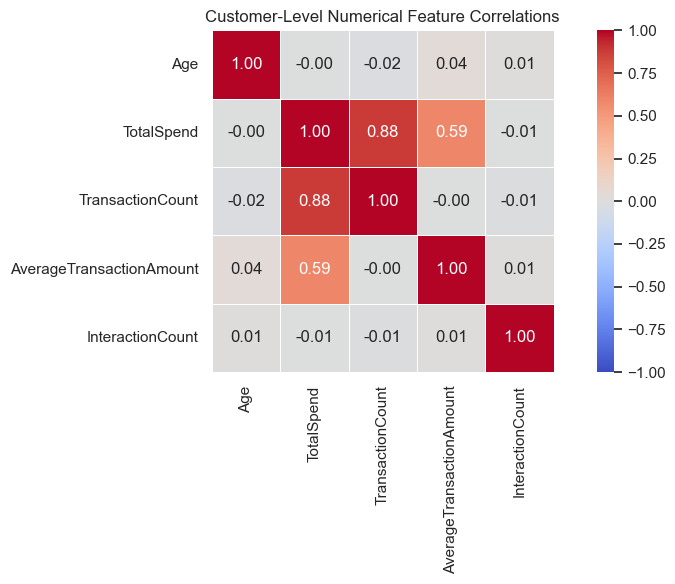

In [55]:
# customer-level correlation
customer_numeric = customer_analysis[
    [
        "Age",
        "TotalSpend",
        "TransactionCount",
        "AverageTransactionAmount",
        "InteractionCount"
    ]
]

correlation_matrix = customer_numeric.corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Customer-Level Numerical Feature Correlations")
plt.tight_layout()

save_figure("customer_level_correlation.png", CROSS_DATASET_DIR)

transaction count and total spend exhibit a strong positive correlation of approximately 0.878 at the customer level. however, this relationship should not be interpreted as an independent behavioral discovery because both variables are constructed from the same underlying transaction records. the association is therefore partly structural: customers with more recorded transactions have more opportunities for their transaction amounts to contribute to total spending.